In [3054]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
sns.set(color_codes=True)
%matplotlib inline 
# sns.set(rc={'figure.figsize':(8,6)})
from sklearn.model_selection import train_test_split

In [3055]:
#To display comments/observations in 'orange' color and bold
def b(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Observations:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")
def f(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Final Comments:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")

In [3056]:
df_org = pd.read_csv('Bank_Personal_Loan_Modelling.csv')

In [3057]:
df_org.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [3059]:
df_org.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [3060]:
b("==> Target variable is 'Personal Loan'. It encompasses binary classes i.e. either to predict if loan was accepted('1') by customer or NOT accepted('0')\n ==> Moved target variable to the end of df header row as last column so that predictor and target columns can be split for model train and test")
df_org = df_org[['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Securities Account',
       'CD Account', 'Online', 'CreditCard', 'Personal Loan']]

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Target variable is 'Personal Loan'. It encompasses binary classes i.e. either to predict if loan was accepted('1') by customer or NOT accepted('0')
 ==> Moved target variable to the end of df header row as last column so that predictor and target columns can be split for model train and test 


In [3061]:
df_org.shape

(5000, 14)

In [3062]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
Personal Loan         5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


### 1. Read the column description and ensure you understand each attribute well

In [3063]:
b("==> There are no null values.\n ==> There are few categorical variables that are considered as 'int' df object.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> There are no null values.
 ==> There are few categorical variables that are considered as 'int' df object. 


In [3064]:
df_org.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Securities Account,5000.0,0.104400,0.305809,0.0,0.00,0.0,0.00,1.0


In [3065]:
b("==> There are negative values in column 'Experience'")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> There are negative values in column 'Experience' 


In [3066]:
df_org.nunique()

ID                    5000
Age                     45
Experience              47
Income                 162
ZIP Code               467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Securities Account       2
CD Account               2
Online                   2
CreditCard               2
Personal Loan            2
dtype: int64

In [3067]:
for i in list(df_org.columns):
    print("\n Column name: '{0}' \n-------------------\n=> No. of unique values: {1}\n=> Unique values: {2}  ".format(i, df_org[i].nunique(), df_org[i].unique()))


 Column name: 'ID' 
-------------------
=> No. of unique values: 5000
=> Unique values: [   1    2    3 ... 4998 4999 5000]  

 Column name: 'Age' 
-------------------
=> No. of unique values: 45
=> Unique values: [25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]  

 Column name: 'Experience' 
-------------------
=> No. of unique values: 47
=> Unique values: [ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]  

 Column name: 'Income' 
-------------------
=> No. of unique values: 162
=> Unique values: [ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15  74  30  38
   9  92  61  73  70

In [3068]:
b("==> There are Categorical variables such as Ordinal-[Education, Securities Account, CD Account, Online, CreditCard], nominal - [ID, ZIP Code] \n ==> There are discrete variables such as Family\n ==> There are continuous variables such as Age, Experience, Income, CCAvg, Mortgage ")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> There are Categorical variables such as Ordinal-[Education, Securities Account, CD Account, Online, CreditCard], nominal - [ID, ZIP Code] 
 ==> There are discrete variables such as Family
 ==> There are continuous variables such as Age, Experience, Income, CCAvg, Mortgage  


In [3069]:
# Converting variable with binary/multi class variables as type 'category'
#df_org[['Education','Securities Account','CD Account','Online','CreditCard','ID','ZIP Code','Personal Loan']] = df_org[['Education','Securities Account','CD Account','Online','CreditCard','ID','ZIP Code','Personal Loan']].astype('category')

In [3070]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
Personal Loan         5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [3071]:
b("==>There are 52 rows with negative values in 'Experience' column")
df_org[df_org['Experience']<0]['Experience'].count()

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==>There are 52 rows with negative values in 'Experience' column 


52

In [3072]:
df_org[df_org['Experience']>=0]['Experience'].count()

4948

In [3073]:
# Convert negative to positive value
df_org['Experience'] = df_org['Experience'].abs()

In [3074]:
df_org[df_org['Experience']<0]['Experience'].count()

0

In [3075]:
df_org[df_org['Experience']>=0]['Experience'].count()

5000

In [3076]:
b("==> There are no duplicate rows in the dataset after converting all values of 'Experience' to positive")
if 'True' in df_org.duplicated().unique().tolist():
    print("There are duplicate rows in the dataset")
else:
    print("There are NO duplicate rows in the dataset")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> There are no duplicate rows in the dataset after converting all values of 'Experience' to positive 
There are NO duplicate rows in the dataset


### 2. Study the data distribution in each attribute, share your findings

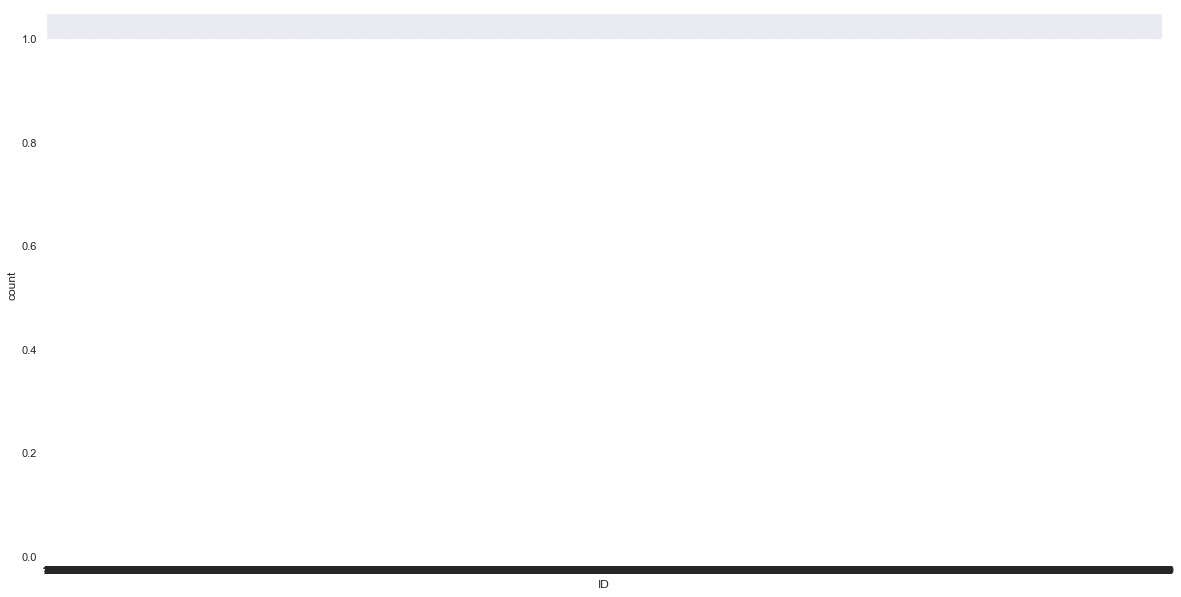

In [3077]:
sns.set(rc={'figure.figsize':(20,10)})
sns.countplot(x='ID', data=df_org)

In [3084]:
b("==>It seems column 'ID' is uniformly distributed and contains only unique data points, which doesn't seem to contribute much for analysis")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==>It seems column 'ID' is uniformly distributed and contains only unique data points, which doesn't seem to contribute much for analysis 


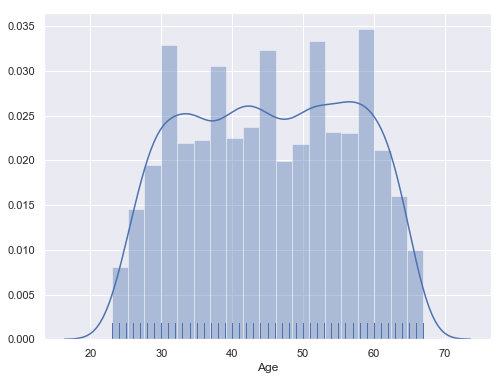

In [3085]:
sns.set(rc={'figure.figsize':(8,6)})
sns.distplot(df_org['Age'], hist=True, kde=True, rug=True)

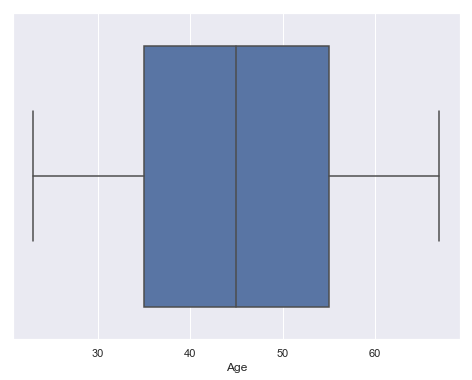

In [3086]:
sns.boxplot(df_org['Age']);

In [3089]:
b("==> It seems that 'Age' is approximately normally distributed across different age bins. However, there are few high frequency in the age bucket 50-60.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> It seems that 'Age' is approximately normally distributed across different age bins. However, there are few high frequency in the age bucket 50-60. 


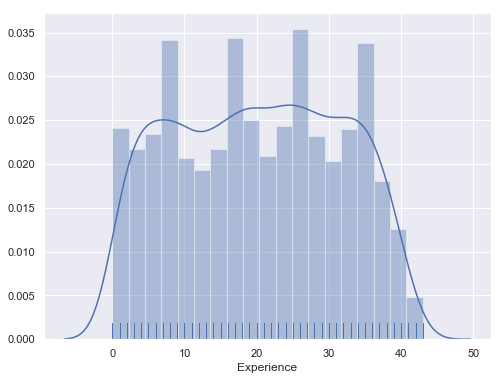

In [3090]:
sns.distplot(df_org['Experience'], hist=True, kde=True, rug=True)

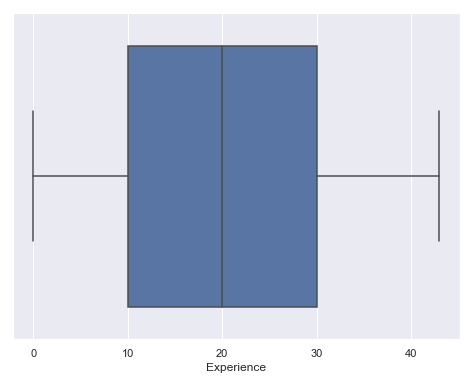

In [3091]:
sns.boxplot(df_org['Experience']);

In [3093]:
b("It seems that 'Experience' is approximately normally distributed across different bins. However, there are few high frequency in the age bucket 15-27.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 It seems that 'Experience' is approximately normally distributed across different bins. However, there are few high frequency in the age bucket 15-27. 


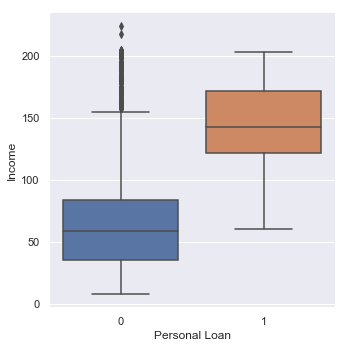

In [3094]:
#sns.distplot(df_org['Income'], hist=True, kde=True, rug=True)
sns.catplot(x='Personal Loan', y='Income', data=df_org, kind='box')

In [3095]:
b("From the above box plot, it's evident that customer whose Annual Income is higher than 120K is historically accepting loan offer by Thera bank.\n Also, the personal loan 'NOT accepted' customer's income distribution is right skewed and personal loan 'accepted' customers income distribution is left skewed and class '0' contains outliers as there are '0' values in income column agsint income class '0'")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 From the above box plot, it's evident that customer whose Annual Income is higher than 120K is historically accepting loan offer by Thera bank.
 Also, the personal loan 'NOT accepted' customer's income distribution is right skewed and personal loan 'accepted' customers income distribution is left skewed and class '0' contains outliers as there are '0' values in income column agsint income class '0' 


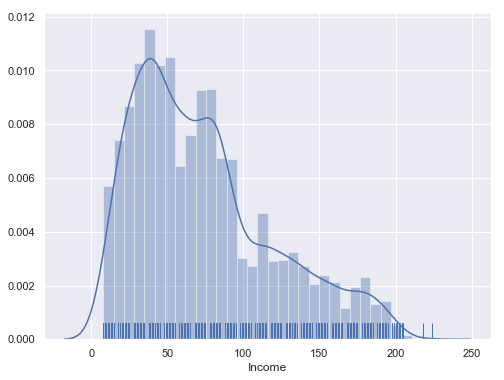

In [3096]:
sns.distplot(df_org['Income'], hist=True, kde=True, rug=True)

In [3097]:
b("Overall annual income seems to be right skewed")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Overall annual income seems to be right skewed 


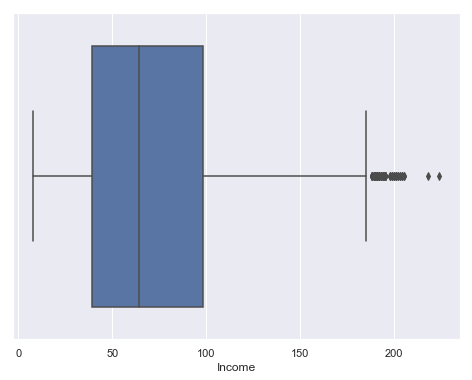

In [3098]:
sns.boxplot(df_org['Income']);

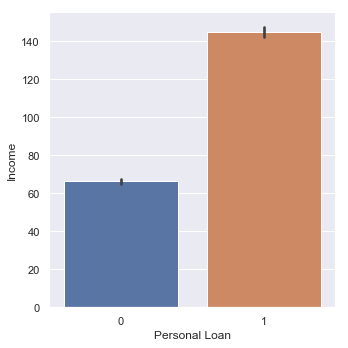

In [3099]:
sns.catplot(y='Income', x='Personal Loan', data=df_org, kind='bar')

In [3100]:
b("Average annual income of personal loan not accepted customers is 68K approx. Average annual income of personal loan accepted customers is 140K approx.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Average annual income of personal loan not accepted customers is 68K approx. Average annual income of personal loan accepted customers is 140K approx. 


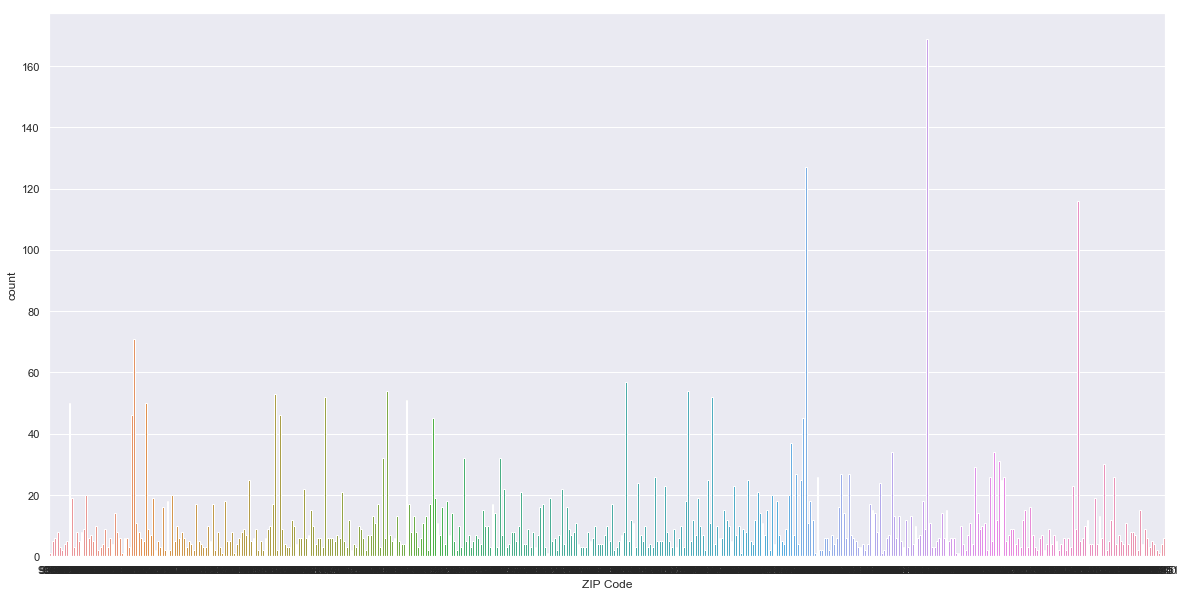

In [2969]:
sns.set(rc={'figure.figsize':(20,10)})
sns.countplot(x=df_org['ZIP Code'])

In [3101]:
b("There are set of records with 120+ records size in each with same ZIP Code. 'ZIP Code' doesn't seem to contribute much for analysis")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 There are set of records with 120+ records size in each with same ZIP Code. 'ZIP Code' doesn't seem to contribute much for analysis 


In [3102]:
df_org.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Securities Account', 'CD Account', 'Online',
       'CreditCard', 'Personal Loan'],
      dtype='object')

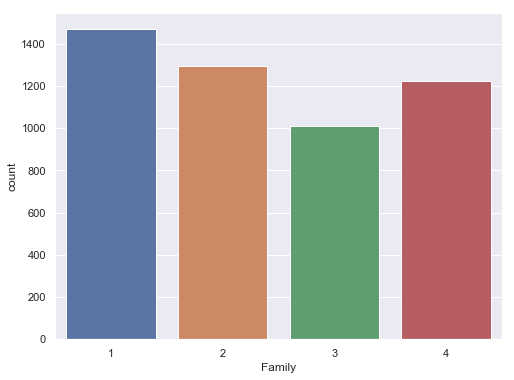

In [3103]:
sns.set(rc={'figure.figsize':(8,6)})
sns.countplot(df_org['Family'])

In [3104]:
b("Column 'Family' contains more records in family size '1' and '2' compared to other two. There is a possiblity that 'Single' or Married couple(wihout children) might potentially accept the loan")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Column 'Family' contains more records in family size '1' and '2' compared to other two. There is a possiblity that 'Single' or Married couple(wihout children) might potentially accept the loan 


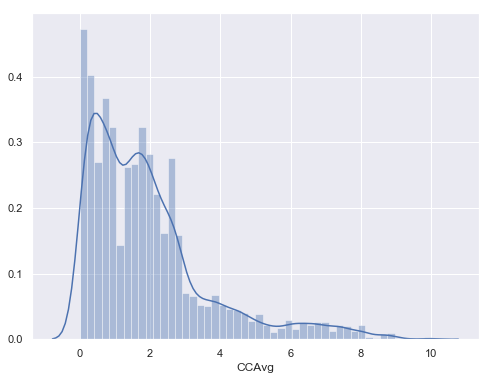

In [3105]:
sns.distplot(df_org['CCAvg'], kde=True)

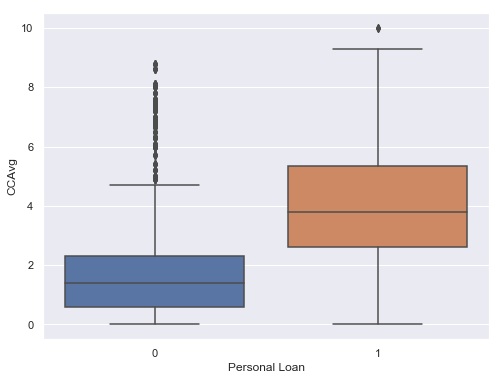

In [3106]:
sns.boxplot(x=df_org['Personal Loan'], y=df_org['CCAvg']);

In [3107]:
#sns.lmplot(x="Income", y="CCAvg",hue="Personal Loan", data=df_org);

In [3108]:
b("It seems 'CCAvg' data points are positively skewed. The money spent through credit card between $300 to #3000 is much higher. However, there are more people that don't use credit card (at point '0' at CCAvg axis)")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 It seems 'CCAvg' data points are positively skewed. The money spent through credit card between $300 to #3000 is much higher. However, there are more people that don't use credit card (at point '0' at CCAvg axis) 


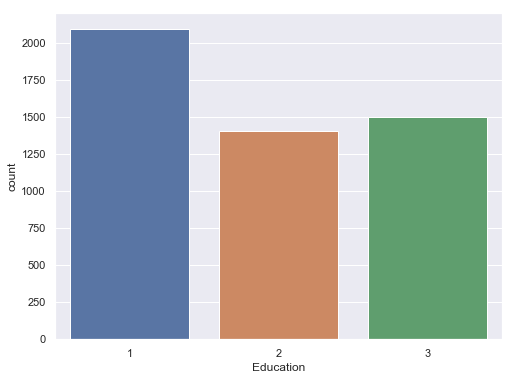

In [3109]:
sns.countplot(x=df_org['Education'])

In [3110]:
b("'Education' column contains more 'Undergrade' and 'Advanced/Professional' than 'Postgrade'. There is a possibility that 'Advanced/Professional' accepting loan")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 'Education' column contains more 'Undergrade' and 'Advanced/Professional' than 'Postgrade'. There is a possibility that 'Advanced/Professional' accepting loan 


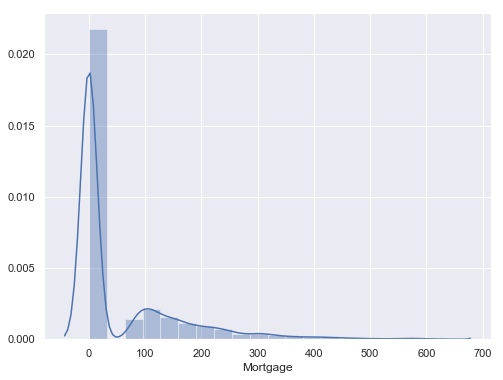

In [3111]:
#With mortgage value '0' considered
sns.distplot(df_org['Mortgage'], bins=20, kde=True)

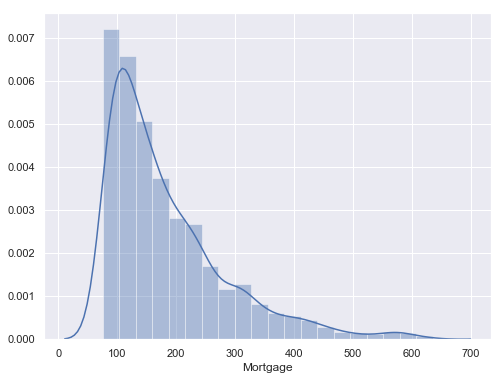

In [3112]:
#Without mortgage value '0' considered
sns.distplot(df_org[df_org['Mortgage']>0]['Mortgage'], bins=20, kde=True)

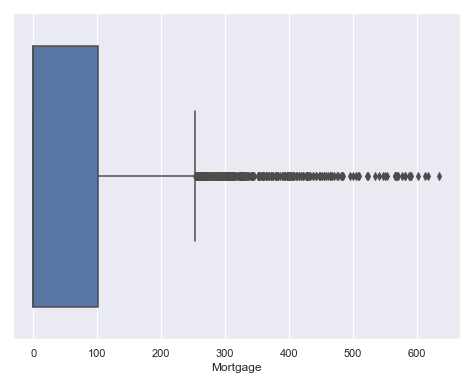

In [3113]:
#With mortgage value '0' considered
sns.boxplot(df_org['Mortgage']);

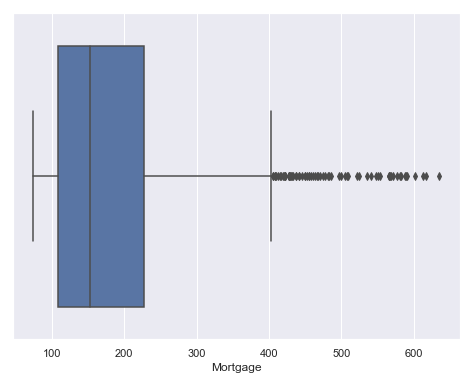

In [3114]:
#Without mortgage value '0' considered
sns.boxplot(df_org[df_org['Mortgage']>0]['Mortgage']);

In [3115]:
b("It seems 'Mortgage' data points are approximately positively skewed and there are very few people that have mortgage worth of $100K-200")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 It seems 'Mortgage' data points are approximately positively skewed and there are very few people that have mortgage worth of $100K-200 


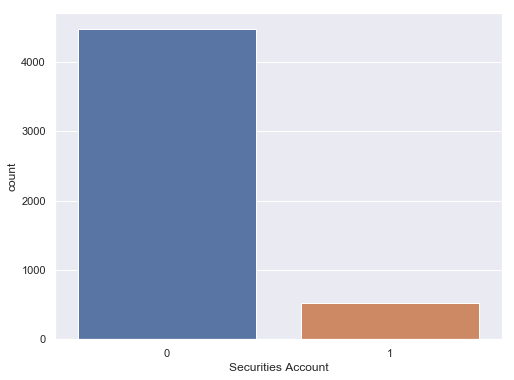

In [3116]:
sns.countplot(df_org['Securities Account'])

In [3117]:
b("There are approx. 4500+ people without having 'Security Account' or 'Trading Account' in the given dataset")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 There are approx. 4500+ people without having 'Security Account' or 'Trading Account' in the given dataset 


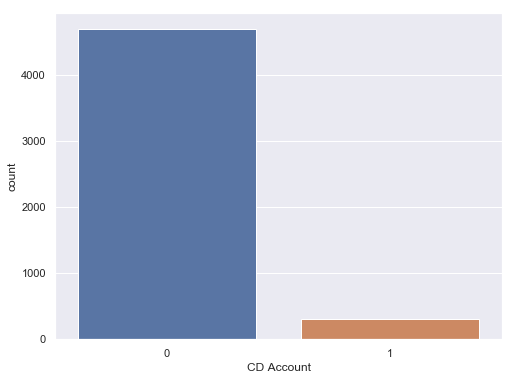

In [3118]:
sns.countplot(df_org['CD Account'])

In [3119]:
b("There are only approx. 300 people, that have 'Certificate of Deposit Account' in the given dataset")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 There are only approx. 300 people, that have 'Certificate of Deposit Account' in the given dataset 


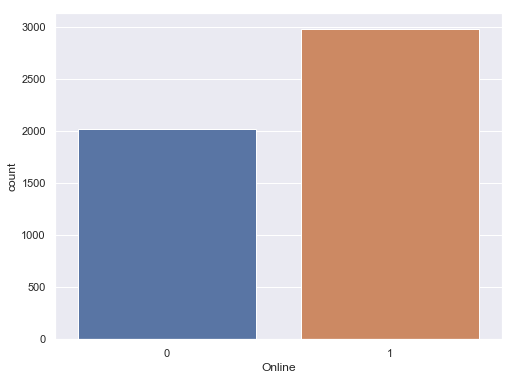

In [3120]:
sns.countplot(df_org['Online'])

In [3121]:
b("There are only approx. 3000 people that use 'Online' platform for banking transactions")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 There are only approx. 3000 people that use 'Online' platform for banking transactions 


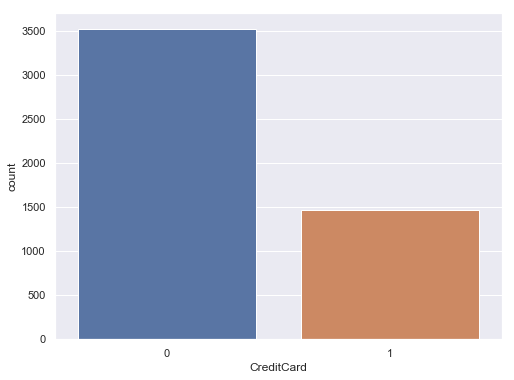

In [3122]:
sns.countplot(df_org['CreditCard'])

In [3123]:
b("There are approx. 1400 people that use 'Credit Card' of 'Thera' bank")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 There are approx. 1400 people that use 'Credit Card' of 'Thera' bank 


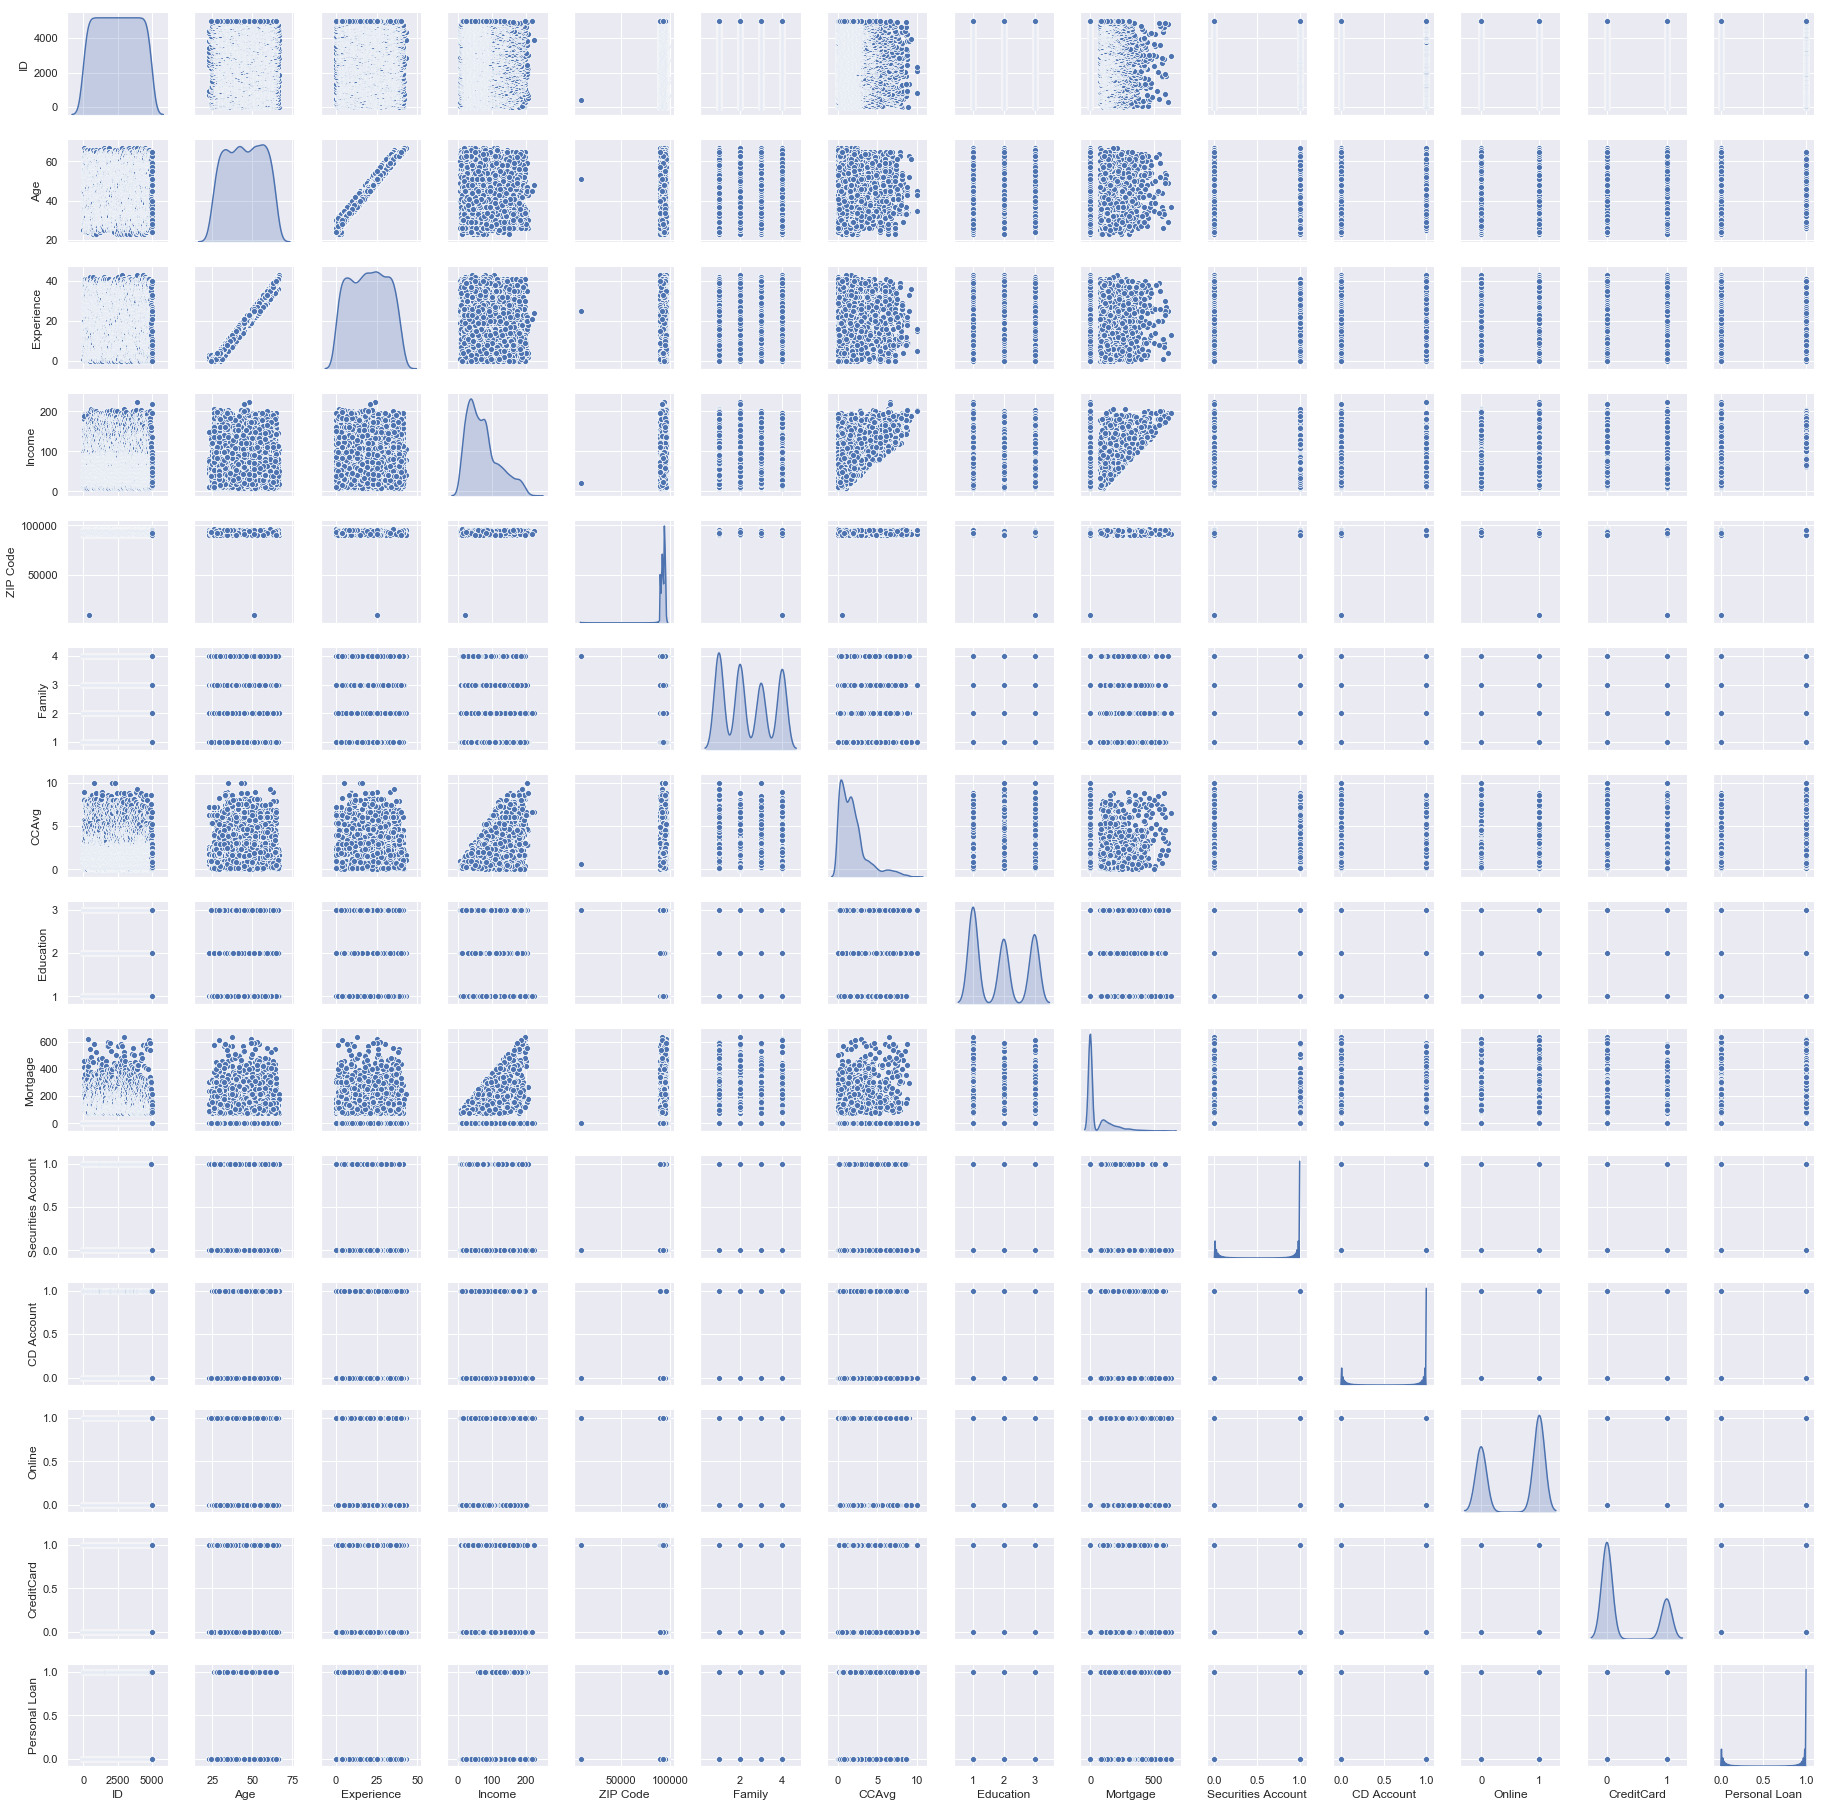

In [2181]:
# Understanding relationship between variables
sns.pairplot(df_org, height=1.8, diag_kind='kde')

In [3124]:
b("It seems that 'Age' and 'Experience' are much correlated and one of them can be dropped off.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 It seems that 'Age' and 'Experience' are much correlated and one of them can be dropped off. 


In [3125]:
b("Dropping unique identifiers such as 'ID' and 'ZIP Code' as these don't contribute much for analysis.\nAlso, 'Age' and 'Experience' columns are highly correlated. Hence, dropping one of them.")
df_org = df_org.drop(['ID', 'ZIP Code', 'Age'], axis=1)

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Dropping unique identifiers such as 'ID' and 'ZIP Code' as these don't contribute much for analysis.
Also, 'Age' and 'Experience' columns are highly correlated. Hence, dropping one of them. 


In [3126]:
df_org.shape

(5000, 11)

#### 3. Get the target column distribution. Your comments

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Totally, there are about 480 customers that have bought loan so far. 


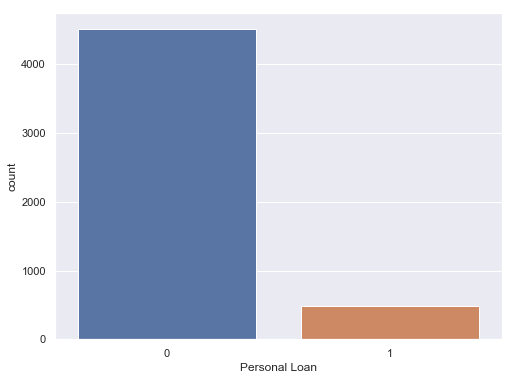

In [3127]:
sns.countplot(df_org['Personal Loan'])
b("Totally, there are about 480 customers that have bought loan so far.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Customers that don't have CD Account have accepted personal loan more compared to those that have CD Account 


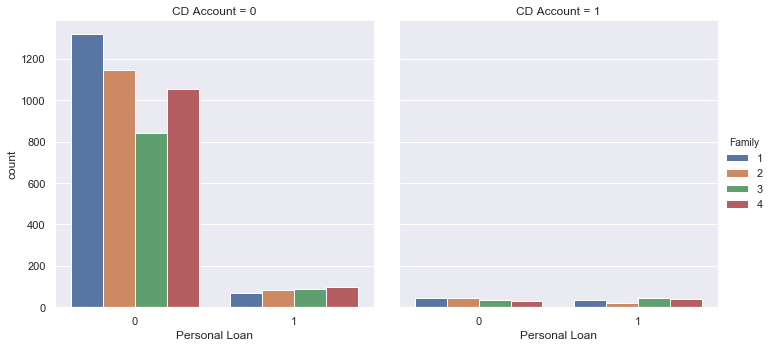

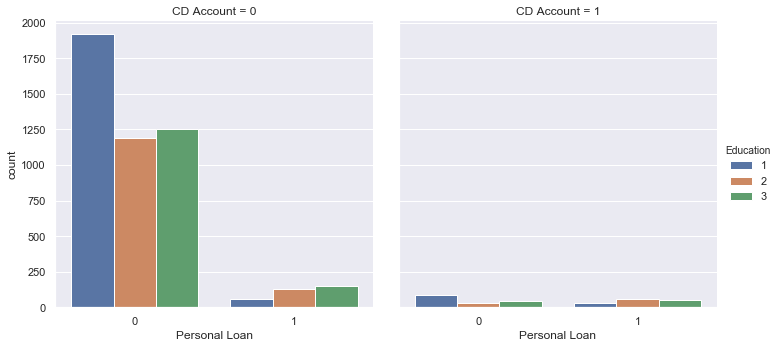

In [3128]:
sns.catplot(x='Personal Loan',  hue='Family', col='CD Account', data=df_org, kind='count')
sns.catplot(x='Personal Loan',  hue='Education', col='CD Account', data=df_org, kind='count')
b("Customers that don't have CD Account have accepted personal loan more compared to those that have CD Account")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Customers that don't have CreditCard have accepted personal loan more compared to those that have CreditCard 


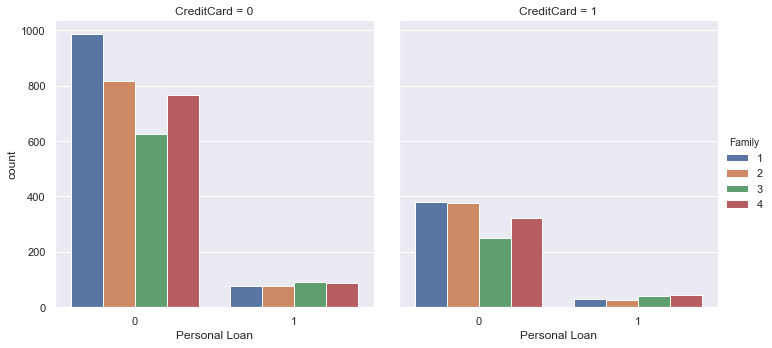

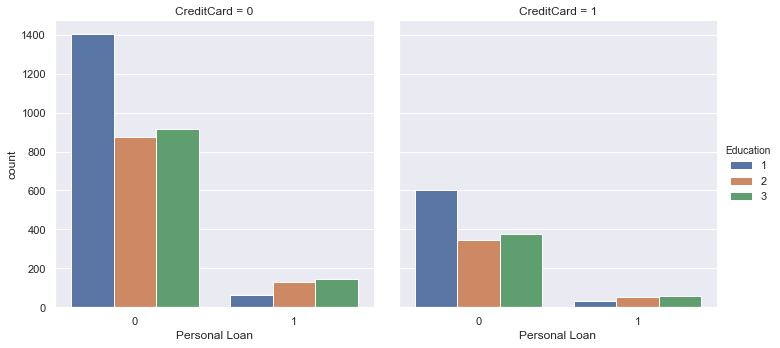

In [3129]:
sns.catplot(x='Personal Loan',  hue='Family', col='CreditCard', data=df_org, kind='count')
sns.catplot(x='Personal Loan',  hue='Education', col='CreditCard', data=df_org, kind='count')
b("Customers that don't have CreditCard have accepted personal loan more compared to those that have CreditCard")

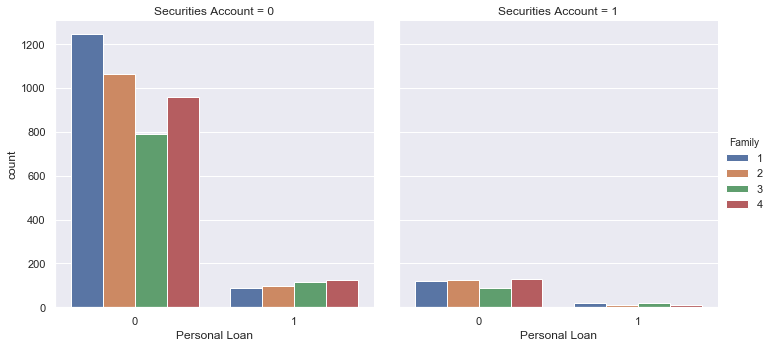

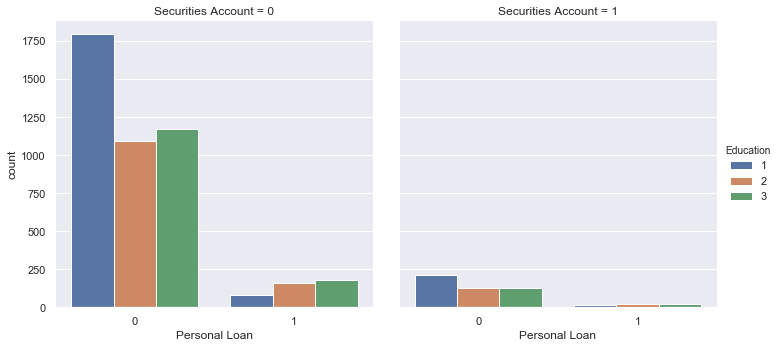

In [3130]:
sns.catplot(x='Personal Loan',  hue='Family', col='Securities Account', data=df_org, kind='count')
sns.catplot(x='Personal Loan',  hue='Education', col='Securities Account', data=df_org, kind='count')

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Customers that have Online have accepted personal loan more compared to those that don't have Online account 


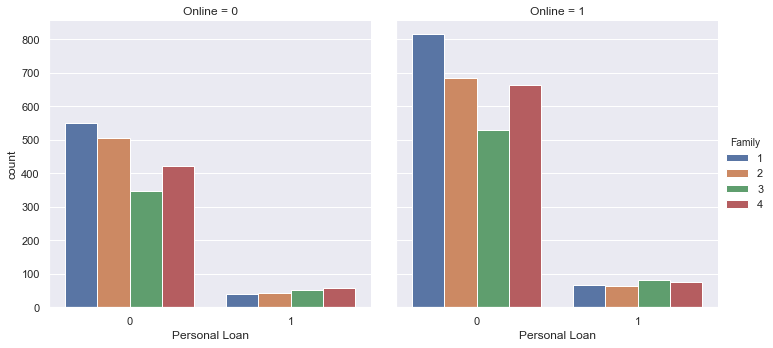

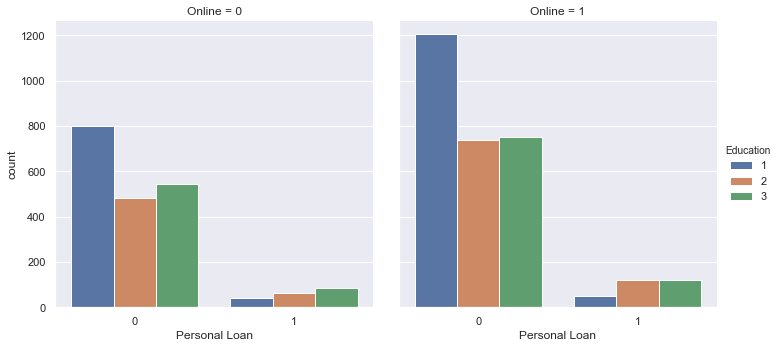

In [3131]:
sns.catplot(x='Personal Loan',  hue='Family', col='Online', data=df_org, kind='count')
sns.catplot(x='Personal Loan',  hue='Education', col='Online', data=df_org, kind='count')
b("Customers that have Online have accepted personal loan more compared to those that don't have Online account")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Customers that have annual income of '>120K' have accepted personal loan more. 


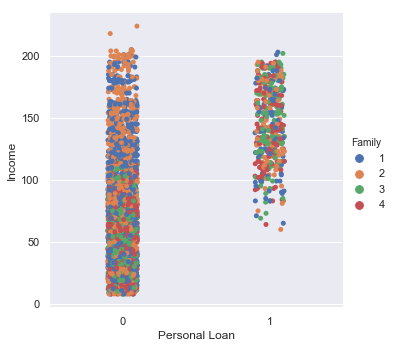

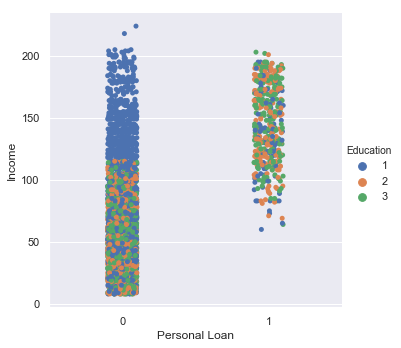

In [3132]:
sns.catplot(x='Personal Loan',  y='Income', hue='Family', data=df_org, jitter=True);
sns.catplot(x='Personal Loan',  y='Income', hue='Education', data=df_org, jitter=True)
b("Customers that have annual income of '>120K' have accepted personal loan more.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 In loan accepted class (1),customers that have education type 2 and 3 and family size 2 and 3 have more 'CCAvg' 


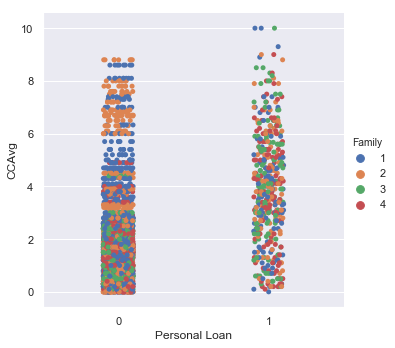

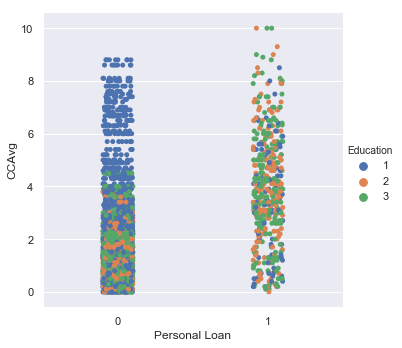

In [3133]:
sns.catplot(x='Personal Loan',  y='CCAvg', hue='Family', data=df_org, jitter=True)
sns.catplot(x='Personal Loan',  y='CCAvg', hue='Education', data=df_org, jitter=True)
b("In loan accepted class (1),customers that have education type 2 and 3 and family size 2 and 3 have more 'CCAvg'")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 In loan accepted class (1),customers that have education type 2 and 3 and family size 2, 3 and 4 have more 'Mortgage' 


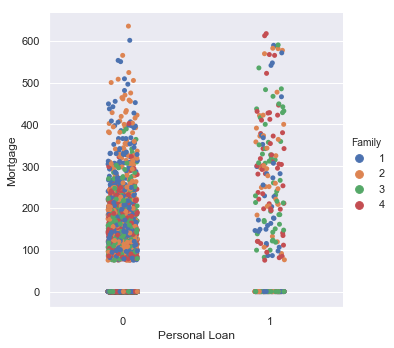

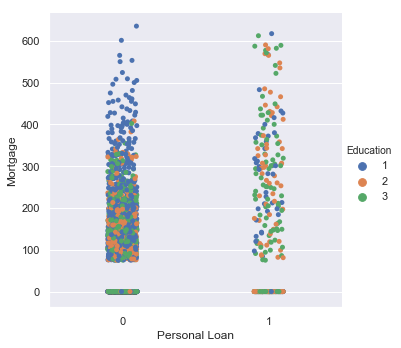

In [3165]:
sns.catplot(x='Personal Loan',  y='Mortgage', hue='Family', data=df_org, jitter=True)
sns.catplot(x='Personal Loan',  y='Mortgage', hue='Education', data=df_org, jitter=True)
b("In loan accepted class (1),customers that have education type 2 and 3 and family size 2, 3 and 4 have more 'Mortgage'")

#### 4. Split the data into training and test set in the ratio of 70:30 respectively

In [3134]:
X = df_org.iloc[:,:-1]
y = df_org.iloc[:,-1:]

In [3135]:
X.columns

Index(['Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage',
       'Securities Account', 'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [3136]:
y.columns

Index(['Personal Loan'], dtype='object')

In [3137]:
#Split the data into training and test set in the ratio of 70:30 respectively
from sklearn import preprocessing

random_st = 42
#Without scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_st)

# MinMax Normalization
min_max_scaler = preprocessing.MinMaxScaler()
X_minmax = pd.DataFrame(min_max_scaler.fit_transform(X))
X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(X_minmax, y, test_size=0.3, random_state=random_st)

# Standard Normalization
std_scaler = preprocessing.StandardScaler()
X_std = pd.DataFrame(std_scaler.fit_transform(X))
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_std, y, test_size=0.3, random_state=random_st)

# Robust Normalization as there are multiple outliers in the dataset
robust_scaler = preprocessing.RobustScaler()
X_robust = pd.DataFrame(robust_scaler.fit_transform(X))
X_train_robust, X_test_robust, y_train_robust, y_test_robust = train_test_split(X_robust, y, test_size=0.3, random_state=random_st)

## 5. Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a customer buying personal loans and 6. Print the confusion matrix for all the above models

In [3138]:
# 1. Logistic Regression - Classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
from time import sleep

perf_model_nm=[]; perf_score=[]

Classification Report: Logistic Regression  - liblinear
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1343
           1       0.87      0.58      0.69       157

   micro avg       0.95      0.95      0.95      1500
   macro avg       0.91      0.78      0.83      1500
weighted avg       0.94      0.95      0.94      1500

Classification Report: Logistic Regression  - lbfgs
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1343
           1       0.82      0.62      0.71       157

   micro avg       0.95      0.95      0.95      1500
   macro avg       0.89      0.80      0.84      1500
weighted avg       0.94      0.95      0.94      1500

Classification Report: Logistic Regression  - newton-cg
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1343
           1       0.85      0.64      0.73       157

   micro avg      

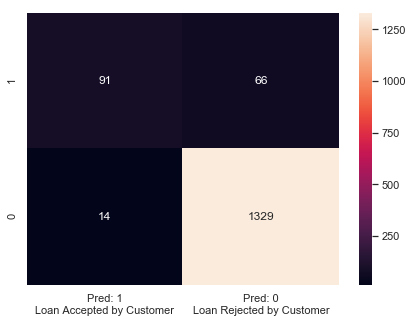

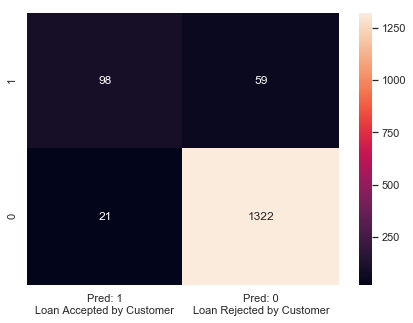

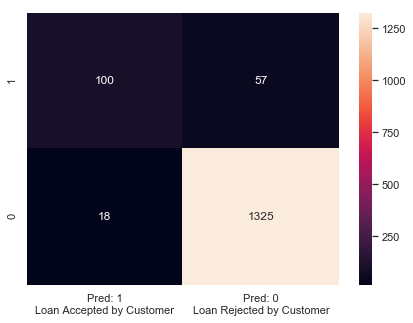

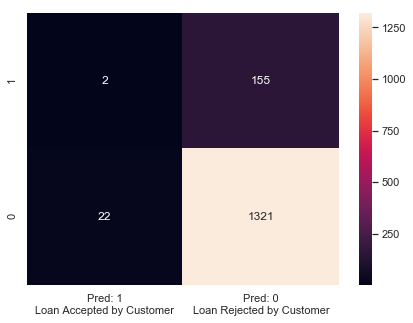

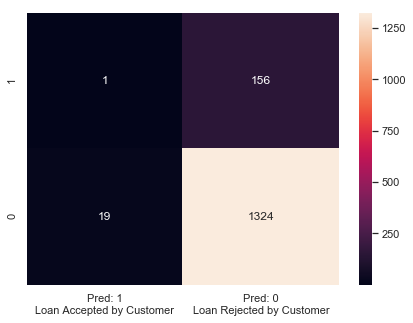

In [3139]:
#Without any scaler
solvers = ['liblinear', 'lbfgs','newton-cg','sag', 'saga']
perf_model_nm_lr=[]; perf_score_lr=[]

for solver_name in solvers:
    logReg = LogisticRegression(solver=solver_name)
    logReg.fit(X_train, y_train)
    y_pred = logReg.predict(X_test)
    target_values = map(str, df_org['Personal Loan'].unique().tolist())
    print("Classification Report: Logistic Regression  - {0}\n{1}".format(solver_name, classification_report(y_test, y_pred, target_names=list(target_values))))
    
    #6. Print the confusion matrix for all the above models
    conf_mat = metrics.confusion_matrix(y_test, y_pred, labels=[1,0])
    df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["1","0"]], columns = [i for i in ["Pred: 1\nLoan Accepted by Customer","Pred: 0\nLoan Rejected by Customer"]])
    plt.figure(figsize = (7,5))
    logReg_ps = metrics.accuracy_score(y_test, y_pred).round(3)
    perf_model_nm_lr.append("Logistic Regression - {0}".format(solver_name))
    perf_score_lr.append(logReg_ps)
    sns.heatmap(df_conf_mat, annot=True, fmt='g')

In [3140]:
print(perf_model_nm_lr, perf_score_lr)

['Logistic Regression - liblinear', 'Logistic Regression - lbfgs', 'Logistic Regression - newton-cg', 'Logistic Regression - sag', 'Logistic Regression - saga'] [0.947, 0.947, 0.95, 0.882, 0.883]


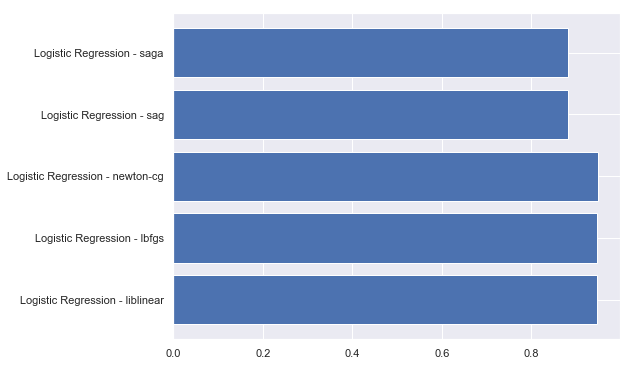

In [3141]:
plt.barh(perf_model_nm_lr, perf_score_lr)
plt.show()

perf_model_nm.append("Logistic Regression - newton-cg")
perf_score.append(perf_score_lr[2])

In [3142]:
b("==> Out of all five Logistic Regression Solvers, it seems 'Newton-cg' performs well in terms of predicting class '1' and '0' comparatively based on f1-score")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Out of all five Logistic Regression Solvers, it seems 'Newton-cg' performs well in terms of predicting class '1' and '0' comparatively based on f1-score 


In [3143]:
# 2. K-Nearest Neighbors - Classifier
from sklearn.neighbors import KNeighborsClassifier

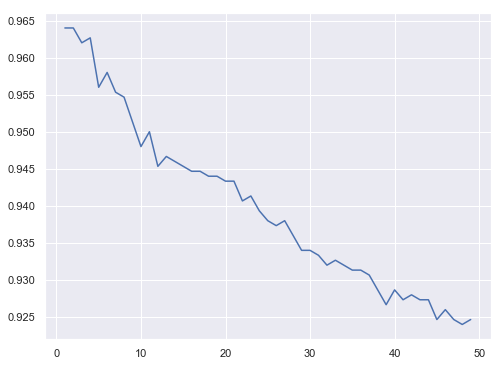

In [3144]:
import warnings
warnings.filterwarnings('ignore')

# Choosing right 'K' value
scores =[]
for k in range(1,50):
    NN_K = KNeighborsClassifier(n_neighbors = k, weights = 'distance')
    NN_K.fit(X_train_minmax, y_train_minmax)
    scores.append(NN_K.score(X_test_minmax, y_test_minmax))
plt.plot(range(1,50),scores)

In [3145]:
b("Based on the above plotting, the best 'K' value seems to be '3'.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 Based on the above plotting, the best 'K' value seems to be '3'. 


Classification Report: KNN - No Scaler
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1343
           1       0.56      0.41      0.48       157

   micro avg       0.90      0.90      0.90      1500
   macro avg       0.75      0.69      0.71      1500
weighted avg       0.89      0.90      0.90      1500

Performance Score of K-NN Classifier:  0.905


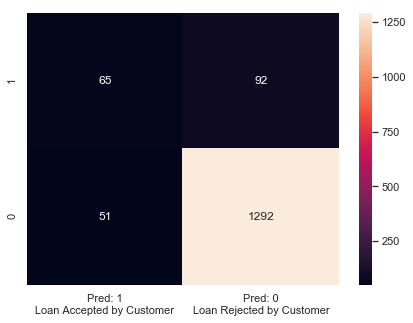

In [3146]:
perf_model_nm_knn=[]; perf_score_knn=[]

scaler_type="No Scaler"
# Using No scaled dataset
knn = KNeighborsClassifier(n_neighbors= 3, weights = 'distance')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
#print(y_pred)
target_values = map(str, df_org['Personal Loan'].unique().tolist())
print("Classification Report: KNN - {0}\n{1}".format(scaler_type,classification_report(y_test, y_pred, target_names=list(target_values))))
conf_mat_knn = metrics.confusion_matrix(y_test, y_pred, labels=[1,0])
df_conf_mat_knn = pd.DataFrame(conf_mat_knn, index = [i for i in ["1","0"]], columns = [i for i in ["Pred: 1\nLoan Accepted by Customer","Pred: 0\nLoan Rejected by Customer"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_conf_mat_knn, annot=True, fmt='g')
knn_ps = metrics.accuracy_score(y_test, y_pred).round(3)
perf_model_nm_knn.append("KNN -{0}".format(scaler_type))
perf_score_knn.append(knn_ps)
print("Performance Score of K-NN Classifier: ", knn_ps)

Classification Report: KNN - MinMax Scaler
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1343
           1       0.98      0.65      0.78       157

   micro avg       0.96      0.96      0.96      1500
   macro avg       0.97      0.82      0.88      1500
weighted avg       0.96      0.96      0.96      1500

Performance Score of K-NN Classifier:  0.962


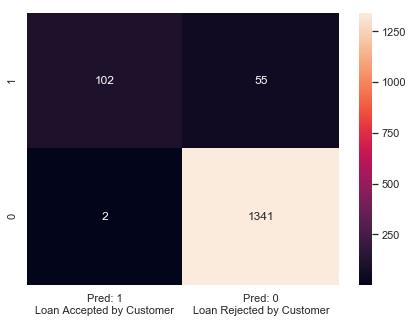

In [3147]:
# Using MinMax scaled dataset
scaler_type="MinMax Scaler"
knn = KNeighborsClassifier(n_neighbors= 3, weights = 'distance')
knn.fit(X_train_minmax, y_train_minmax)
y_pred_minmax = knn.predict(X_test_minmax)
#print(y_pred)
target_values = map(str, df_org['Personal Loan'].unique().tolist())
print("Classification Report: KNN - {0}\n{1}".format(scaler_type,classification_report(y_test_minmax, y_pred_minmax, target_names=list(target_values))))
conf_mat_knn = metrics.confusion_matrix(y_test_minmax, y_pred_minmax, labels=[1,0])
df_conf_mat_knn = pd.DataFrame(conf_mat_knn, index = [i for i in ["1","0"]], columns = [i for i in ["Pred: 1\nLoan Accepted by Customer","Pred: 0\nLoan Rejected by Customer"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_conf_mat_knn, annot=True, fmt='g')
knn_ps = metrics.accuracy_score(y_test_minmax, y_pred_minmax).round(3)
perf_model_nm_knn.append("KNN -{0}".format(scaler_type))
perf_score_knn.append(knn_ps)
print("Performance Score of K-NN Classifier: ", knn_ps)

Classification Report: KNN - Standard Normal Scaler
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1343
           1       0.93      0.67      0.78       157

   micro avg       0.96      0.96      0.96      1500
   macro avg       0.95      0.83      0.88      1500
weighted avg       0.96      0.96      0.96      1500

Performance Score of K-NN Classifier:  0.96


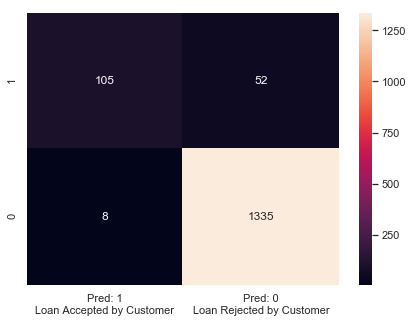

In [3148]:
# Using Standard Normalization scaled dataset
scaler_type="Standard Normal Scaler"
knn = KNeighborsClassifier(n_neighbors= 3, weights = 'distance')
knn.fit(X_train_std, y_train_std)
y_pred_std = knn.predict(X_test_std)
#print(y_pred)
target_values = map(str, df_org['Personal Loan'].unique().tolist())
print("Classification Report: KNN - {0}\n{1}".format(scaler_type, classification_report(y_test_std, y_pred_std, target_names=list(target_values))))
conf_mat_knn = metrics.confusion_matrix(y_test_std, y_pred_std, labels=[1,0])
df_conf_mat_knn = pd.DataFrame(conf_mat_knn, index = [i for i in ["1","0"]], columns = [i for i in ["Pred: 1\nLoan Accepted by Customer","Pred: 0\nLoan Rejected by Customer"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_conf_mat_knn, annot=True, fmt='g')
knn_ps = metrics.accuracy_score(y_test, y_pred_std).round(3)
perf_model_nm_knn.append("KNN -{0}".format(scaler_type))
perf_score_knn.append(knn_ps)
print("Performance Score of K-NN Classifier: ", knn_ps)

Classification Report: KNN - Robust Scaler
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1343
           1       0.93      0.62      0.75       157

   micro avg       0.96      0.96      0.96      1500
   macro avg       0.95      0.81      0.86      1500
weighted avg       0.96      0.96      0.95      1500

Performance Score of K-NN Classifier:  0.956


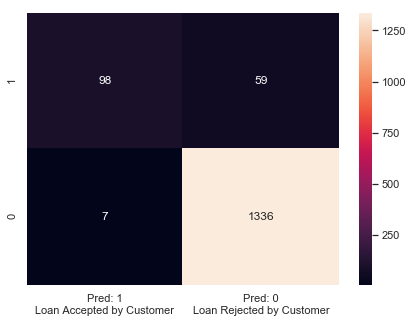

In [3149]:
# Using Robust scaled dataset
scaler_type="Robust Scaler"
knn = KNeighborsClassifier(n_neighbors= 3, weights = 'distance')
knn.fit(X_train_robust, y_train_robust)
y_pred_robust = knn.predict(X_test_robust)
#print(y_pred)
target_values = map(str, df_org['Personal Loan'].unique().tolist())
print("Classification Report: KNN - {0}\n{1}".format(scaler_type, classification_report(y_test_robust, y_pred_robust, target_names=list(target_values))))
conf_mat_knn = metrics.confusion_matrix(y_test_robust, y_pred_robust, labels=[1,0])
df_conf_mat_knn = pd.DataFrame(conf_mat_knn, index = [i for i in ["1","0"]], columns = [i for i in ["Pred: 1\nLoan Accepted by Customer","Pred: 0\nLoan Rejected by Customer"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_conf_mat_knn, annot=True, fmt='g')
knn_ps = metrics.accuracy_score(y_test_robust, y_pred_robust).round(3)
perf_model_nm_knn.append("KNN - {0}".format(scaler_type))
perf_score_knn.append(knn_ps)
print("Performance Score of K-NN Classifier: ", knn_ps)

In [3150]:
print(perf_model_nm_knn,perf_score_knn)

['KNN -No Scaler', 'KNN -MinMax Scaler', 'KNN -Standard Normal Scaler', 'KNN - Robust Scaler'] [0.905, 0.962, 0.96, 0.956]


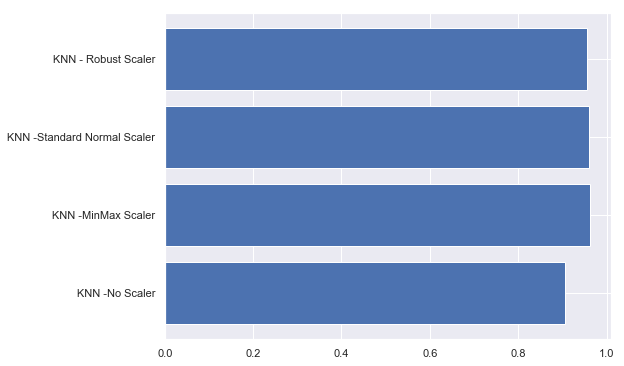

In [3151]:
plt.barh(perf_model_nm_knn, perf_score_knn)
plt.show()
perf_model_nm.append("KNN -Standard Normal Scaler")
perf_score.append(perf_score_knn[2])

In [3152]:
b("==> Out of all four Scaler techiniques(No Scaler, MinMax Scaler, Standard Normal Scaler, Robust Scaler), KNN produces better results in terms of predicting class '1' and '0' on 'Standard Normal Scaled' dataset based on f1-score")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Out of all four Scaler techiniques(No Scaler, MinMax Scaler, Standard Normal Scaler, Robust Scaler), KNN produces better results in terms of predicting class '1' and '0' on 'Standard Normal Scaled' dataset based on f1-score 


Classification Report: Naive Bayes - GaussianNB
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1343
           1       0.67      0.20      0.31       157

   micro avg       0.91      0.91      0.91      1500
   macro avg       0.79      0.59      0.63      1500
weighted avg       0.89      0.91      0.88      1500

Performance Score of Naive Bayes:  0.91
Classification Report: Naive Bayes - BernoulliNB
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1343
           1       0.67      0.20      0.31       157

   micro avg       0.91      0.91      0.91      1500
   macro avg       0.79      0.59      0.63      1500
weighted avg       0.89      0.91      0.88      1500

Performance Score of Naive Bayes:  0.91
Classification Report: Naive Bayes - MultinomialNB
              precision    recall  f1-score   support

           0       0.90      1.00      0.94      1343
         

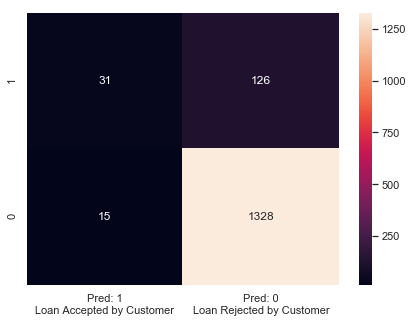

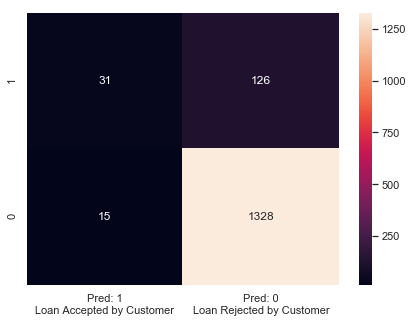

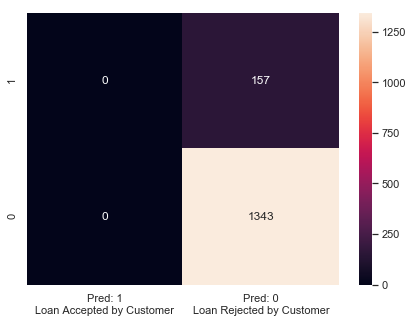

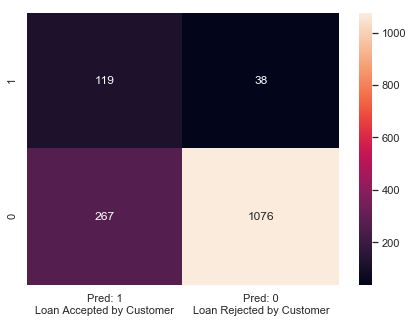

In [3153]:
# 3. Naive Bayes - Classifier
perf_model_nm_nb=[]; perf_score_nb=[]

from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB, ComplementNB
classifier_types = ['GaussianNB', 'BernoulliNB', 'MultinomialNB', 'ComplementNB']
for classifier_type in classifier_types:
    if classifier_type == 'GaussianNB':
        nb = BernoulliNB()
    elif classifier_type == 'BernoulliNB':
        nb = BernoulliNB()
    elif classifier_type == 'MultinomialNB':
        nb = MultinomialNB()
    elif classifier_type == 'ComplementNB':
        nb = ComplementNB()
    else:
        print("Invalid classifier.")
    nb.fit(X_train_minmax, y_train_minmax)
    y_pred_minmax = nb.predict(X_test_minmax)
    #print(y_pred)
    target_values = map(str, df_org['Personal Loan'].unique().tolist())
    print("Classification Report: Naive Bayes - {0}\n{1}".format(classifier_type, classification_report(y_test_minmax, y_pred_minmax, target_names=list(target_values))))
    conf_mat_nb = metrics.confusion_matrix(y_test_minmax, y_pred_minmax, labels=[1,0])
    df_conf_mat_nb = pd.DataFrame(conf_mat_nb, index = [i for i in ["1","0"]], columns = [i for i in ["Pred: 1\nLoan Accepted by Customer","Pred: 0\nLoan Rejected by Customer"]])
    plt.figure(figsize = (7,5))
    sns.heatmap(df_conf_mat_nb, annot=True, fmt='g')
    nb_ps = metrics.accuracy_score(y_test_minmax, y_pred_minmax).round(2)
    perf_model_nm_nb.append("Naive Bayes - {0}".format(classifier_type))
    perf_score_nb.append(nb_ps)
    print("Performance Score of Naive Bayes: ", nb_ps)

In [3154]:
print(perf_model_nm_nb, perf_score_nb)

['Naive Bayes - GaussianNB', 'Naive Bayes - BernoulliNB', 'Naive Bayes - MultinomialNB', 'Naive Bayes - ComplementNB'] [0.91, 0.91, 0.9, 0.8]


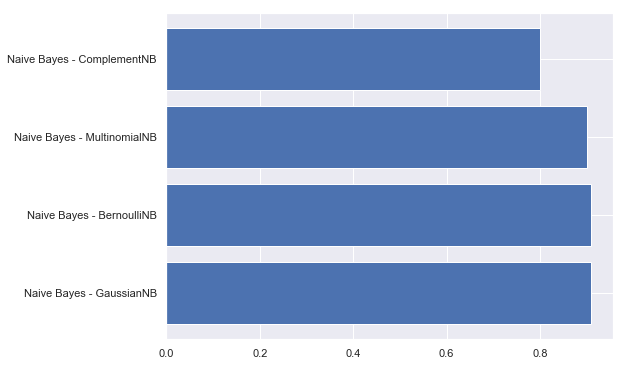

In [3155]:
plt.barh(perf_model_nm_nb, perf_score_nb)
plt.show()
perf_model_nm.append("Naive Bayes - ComplementNB")
perf_score.append(perf_score_nb[3])

In [3156]:
b("==> Out of all four NB classifiers('GaussianNB', 'BernoulliNB', 'MultinomialNB', 'ComplementNB'), 'ComplementNB' classifier gives good results in terms of predicting class '1' and '0' on 'MinMax Scaler' dataset based on f1-score eventhough the overall model performance score of 'Complement NB' is lesser compared to other classifiers")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Out of all four NB classifiers('GaussianNB', 'BernoulliNB', 'MultinomialNB', 'ComplementNB'), 'ComplementNB' classifier gives good results in terms of predicting class '1' and '0' on 'MinMax Scaler' dataset based on f1-score eventhough the overall model performance score of 'Complement NB' is lesser compared to other classifiers 


#### 7. Give your reasoning on which is the best model in this case and why it performs better?

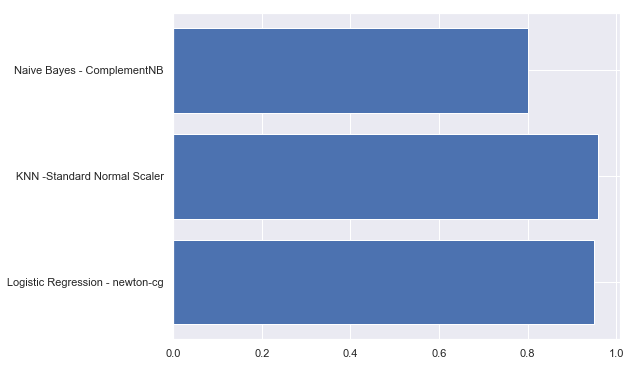

In [3159]:
plt.barh(perf_model_nm, perf_score)
plt.show()

In [3164]:
f("==> By looking at the overall performance of above three models (NB, KNN, LogistricRegression), KNN on Standard Normal Scaled dataset outperforms other models. As far as EDA and feature normalization approch go, the dataset contains different column types such as Categorical(ordinal-Education, CreditCard, Securities Account, etc.), Contineous(Income, CCAvg), Discrete(Family). Even though, ComplimentNB and LogisticRegression-Newton-CG models gave good accuracry score, they failed to maintain overall prediction metrics in both class 1 and 0. ComplementNB performed well in predicting class '1' and Logistic Regression performed good in predicting class '0' but KNN performed excellent in decisioning and predicting both the classes(1 and 0) with minimal errors on mediocre sized-scaled dataset.")

 *********************************************************************************************************************** 
 Final Comments: 
 *********************************************************************************************************************** 
 ==> By looking at the overall performance of above three models (NB, KNN, LogistricRegression), KNN on Standard Normal Scaled dataset outperforms other models. As far as EDA and feature normalization approch go, the dataset contains different column types such as Categorical(ordinal-Education, CreditCard, Securities Account, etc.), Contineous(Income, CCAvg), Discrete(Family). Even though, ComplimentNB and LogisticRegression-Newton-CG models gave good accuracry score, they failed to maintain overall prediction metrics in both class 1 and 0. ComplementNB performed well in predicting class '1' and Logistic Regression performed good in predicting class '0' but KNN performed excellent in decisioning and predicting both the classes(1